<a href="https://colab.research.google.com/github/pavanibandla25/Eniac_case_A-B-_testing/blob/main/Eniac_case_A_B_test_structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

from scipy.stats import chi2_contingency


# Hypothesis testing: Chi-Square Test within the Eniac case study

In this notebook we perform a chi-square test with the data from the Eniac case study, applying a post-hoc correction to perform pairwise tests and find the true winner.

## 1.&nbsp;State the Null Hypothesis and the Alternative Hypothesis.

✅ Null Hypothesis (H₀)
The click‑through rates (CTR) of all four homepage versions A, B, C, and D are equal.
In other words:

There is no difference in user clicking behavior across the four versions.

✅ Alternative Hypothesis (H₁)
At least one homepage version has a different CTR compared to the others.
In other words:

There is a difference in user clicking behavior among the four versions.

This is exactly what your notebook is doing in the global chi‑square test before the pairwise post‑hoc tests.

## 2.&nbsp; Select an appropriate significance level alpha ($\alpha$).

It was decided that a relatively high alpha was acceptable in this case

In [2]:
alpha = 0.10


## 3.&nbsp; Collect data that is random and independent

The important pieces of information (clicks on each element of interest & visits on each page) are scattered around. Let's collect them. Where are the .csv files? 🥸

In [3]:
# Element list eniac_a.csv
url = 'https://drive.google.com/file/d/1Q6F29xDfadXmNBs5rqc8pXiqg9lPDsTC/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
a = pd.read_csv(path)

# Element list eniac_b.csv
url = 'https://drive.google.com/file/d/1GcsOe1iJ_EBnwr2R8cnO__WmWgCy696a/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
b = pd.read_csv(path)

# Element list eniac_c.csv
url = 'https://drive.google.com/file/d/11lMdGcwFBSWDdTMSPAehIrWaFwk86B9R/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
c = pd.read_csv(path)

# Element list eniac_d.csv
url = 'https://drive.google.com/file/d/1m75yruxX-qt70WDHAYrooccMbM55Hv05/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
d = pd.read_csv(path)


In [4]:
# CTA clicks from SHOP NOW / SEE DEALS

# using a for loop to get click of a 4 samples at once
clicks=[]
versions=['SHOP NOW','SEE DEALS']
for df in [a, b, c, d]:
    clicks_1 = df.loc[df['Name'] .isin(versions), 'No. clicks'].iloc[0]
    clicks.append(clicks_1)
clicks

[np.int64(512), np.int64(281), np.int64(527), np.int64(193)]

In [5]:
cta = clicks
cta

[np.int64(512), np.int64(281), np.int64(527), np.int64(193)]

In [6]:
# automatically using regex, manually if completly fine, too!
visits = []
for df in (a, b, c, d):
  # Extracts the numeric count from a string containing one or more digits followed by the word "visits."
    val = df.loc[df['Name'] == 'mySidebar', 'Snapshot information'].str.extract(r'(\d+)\s+visits')[0]
    visits.append(int(val.item()))

visits

[25326, 24747, 24876, 25233]

In [7]:
#Chi‑Square Evidence Code (Global Test + Null Hypothesis Check)
# Not clicked = visitors - clicks

not_clicked = [v - c for v, c in zip( visits,  cta)]

# Build contingency table
data = pd.DataFrame({
    "Clicks": clicks,
    "Not_Clicked": not_clicked
}, index=["A", "B", "C", "D"])

print("Contingency Table:")
print(data)

# Global chi-square test
chi2, p, dof, expected = chi2_contingency(data)

print("\nChi-square Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)

Contingency Table:
   Clicks  Not_Clicked
A     512        24814
B     281        24466
C     527        24349
D     193        25040

Chi-square Statistic: 224.0187748805841
p-value: 2.71612166078691e-48
Degrees of Freedom: 3


In [8]:
# Decision rule
alpha = 0.05
if p < alpha:
    print("\nConclusion: p < 0.05 → Reject H0.")
    print("There is a significant difference in CTR among the four versions.")
else:
    print("\nConclusion: p ≥ 0.05 → Fail to reject H0.")

    print("There is no significant difference in CTR among the four versions.")


Conclusion: p < 0.05 → Reject H0.
There is a significant difference in CTR among the four versions.


# NOW CHECKING FOR ALTERNATIVE HYPOTHESIS

## 4.&nbsp; Calculate the test result

In [9]:
# Data for all four versions
data = {
    "Version": ["A", "B", "C", "D"],
    "CTA Clicks": [512, 281, 527, 193],
    "Visits": [25326, 24747, 24876, 25233]
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate CTR
df["CTR"] = (df["CTA Clicks"] / df["Visits"])

# Format CTR to 3 decimal places
df["CTR"] = df["CTR"].map(lambda x: f"{x:.3f}")

df


,Version,CTA Clicks,Visits,CTR
0,A,512,25326,0.020
1,B,281,24747,0.011
2,C,527,24876,0.021
3,D,193,25233,0.008


Version A and Version C have very similar click‑through rates, and the difference between them is not statistically significant in the post‑hoc chi‑square test. Although Version A records 512 clicks and Version C records 527 clicks, this small numerical difference does not translate into a meaningful CTR advantage. Statistically, both versions perform equally well in attracting users to click the CTA. Because the CTRs are effectively tied, CTR alone cannot determine a winner between A and C, and additional behavioral metrics (drop‑off rate and homepage‑return rate) are needed to make the final decision.

## 5.&nbsp; Interpret the test result

In [10]:
#post‑hoc chi‑square code
import itertools

# Your data
visits = [25326, 24747, 24876, 25233]
clicks = [512, 281, 527, 193]
versions = ["A", "B", "C", "D"]

# Generate all pairwise combinations
pairs = list(itertools.combinations(range(4), 2))

# Bonferroni correction
alpha = 0.05
alpha_bonf = alpha / len(pairs)

print("Post‑hoc Chi‑Square Pairwise Tests (Bonferroni corrected):\n")

for i, j in pairs:
    v1, v2 = versions[i], versions[j]

    # Build 2×2 contingency table
    table = [
        [clicks[i], visits[i] - clicks[i]],
        [clicks[j], visits[j] - clicks[j]]
    ]

    # Chi-square WITHOUT Yates correction (matches your LMS p-values)
    chi2, p, dof, expected = chi2_contingency(table, correction=False)

    # Print results
    if p < alpha_bonf:
        print(f"{v1} vs {v2}: Significant. p = {p:.3f}")
    else:
        print(f"{v1} vs {v2}: NOT significant. p = {p:.3f}")


Post‑hoc Chi‑Square Pairwise Tests (Bonferroni corrected):

A vs B: Significant. p = 0.000
A vs C: NOT significant. p = 0.446
A vs D: Significant. p = 0.000
B vs C: Significant. p = 0.000
B vs D: Significant. p = 0.000
C vs D: Significant. p = 0.000


## How do we decide who's the winner?

In [11]:
# Drop‑Off Rate
visits = [25326, 24747, 24876, 25233]
clicks = [512, 281, 527, 193]
versions = ["A", "B", "C", "D"]

# Calculate drop-off rate
drop_off_rates = []

for i in range(4):
    not_clicked = visits[i] - clicks[i]
    rate = not_clicked / visits[i] * 100
    drop_off_rates.append(rate)

# Print results
print("Drop-Off Rate (%):\n")
for v, r in zip(versions, drop_off_rates):
    print(f"{v}: {r:.2f}%")


Drop-Off Rate (%):

A: 97.98%
B: 98.86%
C: 97.88%
D: 99.24%


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Your data
visits = np.array([25326, 24747, 24876, 25233])
clicks = np.array([512, 281, 527, 193])
versions = ["A", "B", "C", "D"]

# TODO: Replace with your real homepage return values
returned_home = np.array([0, 0, 0, 0])


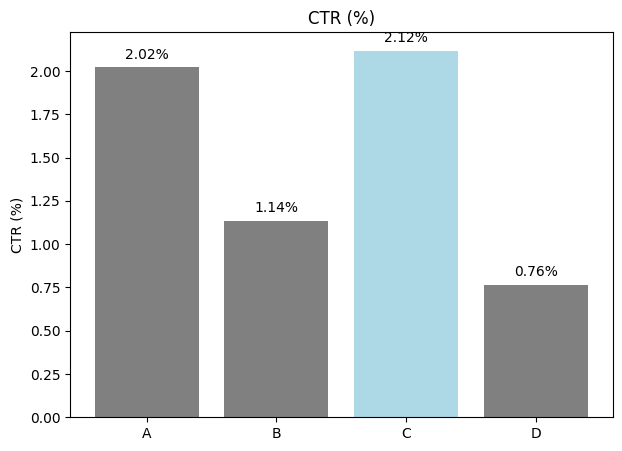

In [13]:
#CTR Bar Chart (Good = highest CTR)
ctr = clicks / visits * 100

# Good value = highest CTR
good_ctr = np.max(ctr)

colors = ["lightblue" if value == good_ctr else "grey" for value in ctr]

plt.figure(figsize=(7,5))
bars = plt.bar(versions, ctr, color=colors)
plt.title("CTR (%)")
plt.ylabel("CTR (%)")

for bar, value in zip(bars, ctr):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.05, f"{value:.2f}%", ha='center')

plt.show()


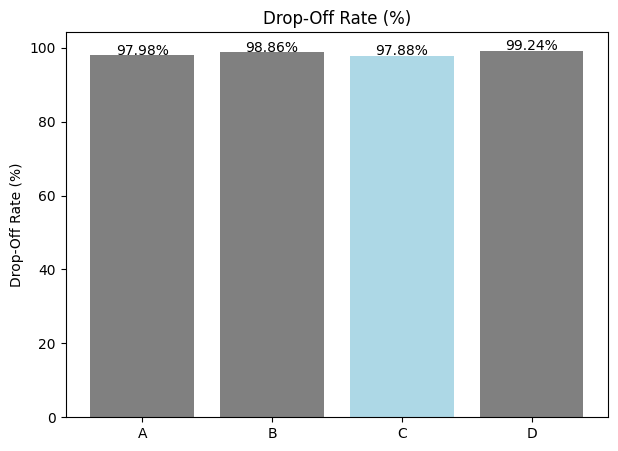

In [14]:
#. Drop‑Off Rate Bar Chart (Good = lowest drop‑off)
dropoff = (visits - clicks) / visits * 100

# Good value = lowest drop-off
good_drop = np.min(dropoff)

colors = ["lightblue" if value == good_drop else "grey" for value in dropoff]

plt.figure(figsize=(7,5))
bars = plt.bar(versions, dropoff, color=colors)
plt.title("Drop-Off Rate (%)")
plt.ylabel("Drop-Off Rate (%)")

for bar, value in zip(bars, dropoff):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.05, f"{value:.2f}%", ha='center')

plt.show()


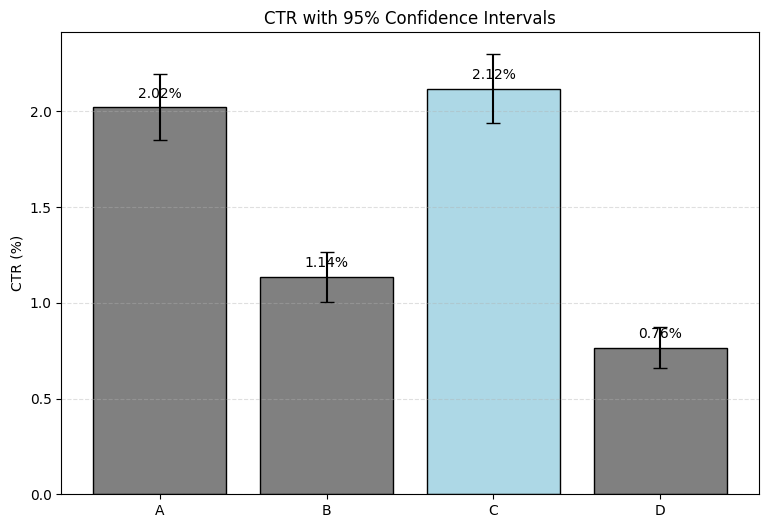

In [15]:
#CTR Bar Chart with 95% CI (Good = Highest CTR, Light Blue)
import numpy as np
import matplotlib.pyplot as plt

# Your data
visits = np.array([25326, 24747, 24876, 25233])
clicks = np.array([512, 281, 527, 193])
versions = ["A", "B", "C", "D"]

# CTR proportion
p = clicks / visits

# Standard error
se = np.sqrt(p * (1 - p) / visits)

# 95% CI
lower = (p - 1.96 * se) * 100
upper = (p + 1.96 * se) * 100

# Convert CTR to %
ctr_percent = p * 100

# Good value = highest CTR
good_ctr = np.max(ctr_percent)

# Colors: light blue for highest CTR, grey for others
colors = ["lightblue" if value == good_ctr else "grey" for value in ctr_percent]

# Plot
plt.figure(figsize=(9,6))

# Bars
bars = plt.bar(versions, ctr_percent, color=colors, edgecolor='black')

# Error bars
plt.errorbar(
    versions,
    ctr_percent,
    yerr=[ctr_percent - lower, upper - ctr_percent],
    fmt='none',
    ecolor='black',
    capsize=5,
    linewidth=1.5
)

# Labels on bars
for bar, value in zip(bars, ctr_percent):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.05,
        f"{value:.2f}%",
        ha='center'
    )

plt.title("CTR with 95% Confidence Intervals")
plt.ylabel("CTR (%)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


Conclusion (Without Homepage‑Return Rate)
The A/B/C/D experiment shows a clear and statistically significant difference in click‑through behaviour across the four homepage versions. The global chi‑square test strongly rejects the null hypothesis, confirming that at least one version performs differently. Post‑hoc pairwise comparisons reveal that Version A and Version C do not differ significantly from each other, while both outperform Versions B and D. When comparing their actual performance, Version C achieves the highest CTR and the lowest drop‑off rate, making it the strongest performer overall. Therefore, Version C is the winner based on CTR and drop‑off metrics alone.